In [1]:
%cd ..
%ls

/home/suetin/Projects/Interview
app_logic.png  Dockerfile       models/       requirements.txt
checkpoints/   docker_utils.py  notebooks/    src/
config.yaml    example.png      __pycache__/  tests/
data/          main.py          README.md     train.py


In [2]:
import torch, yaml, os, pickle
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms

import faiss

from src.model import ViTContrastive
from src.dataset import ContrastiveDataset
from src.steps import train_one_epoch, validate, inference_embeddings

In [3]:
torch.manual_seed(777)

In [4]:
# Load config
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

In [5]:
# 
train_dataset = ContrastiveDataset(root_dir=cfg['train_dir'], n_neg=3)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=4, drop_last=True)

In [6]:
batch = next(iter(train_dataset))
batch.keys(), batch['anchor'].shape

(dict_keys(['anchor', 'positive', 'negatives', 'class_idx']),
 torch.Size([3, 224, 224]))

In [7]:
train_dataset.dataset.classes

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

## Train and Inference

In [8]:
# For training model, use train.py
# %run train.py

In [ ]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = ViTContrastive()
model.load_state_dict(torch.load(cfg['model_path'], map_location=device))
model.to(device)
model.eval()

# Load validation dataset
val_dataset = ContrastiveDataset(cfg['valid_dir'], n_neg=3)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Get embeddings
embeddings, labels = inference_embeddings(model, train_loader, device)  # shape [N, D]
embeddings_np = embeddings.numpy().astype(np.float32)
# Save embeds if we need
# with open("data/embeddings.pkl", "wb") as f:
#     pickle.dump((embeddings_np, labels), f)
#     print("Embeddings saved to data/embeddings.pkl")
embeddings.shape, labels.shape

/home/suetin/Projects/Interview/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/suetin/Projects/Interview/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Embedding: 100%|██████████| 119/119 [00:11<00:00, 10.81it/s]


(torch.Size([3808, 128]), torch.Size([3808]))

In [ ]:
# del embeddings_np

# Load embeddings
# with open("data/embeddings.pkl", "rb") as f:
#     embeddings_np, labels = pickle.load(f)
#     print("Embeddings loaded to data/embeddings.pkl")

In [12]:
# Build Faiss index
faiss.normalize_L2(embeddings_np)  # required for cosine similarity
index = faiss.IndexFlatIP(embeddings_np.shape[1])
index.add(embeddings_np)

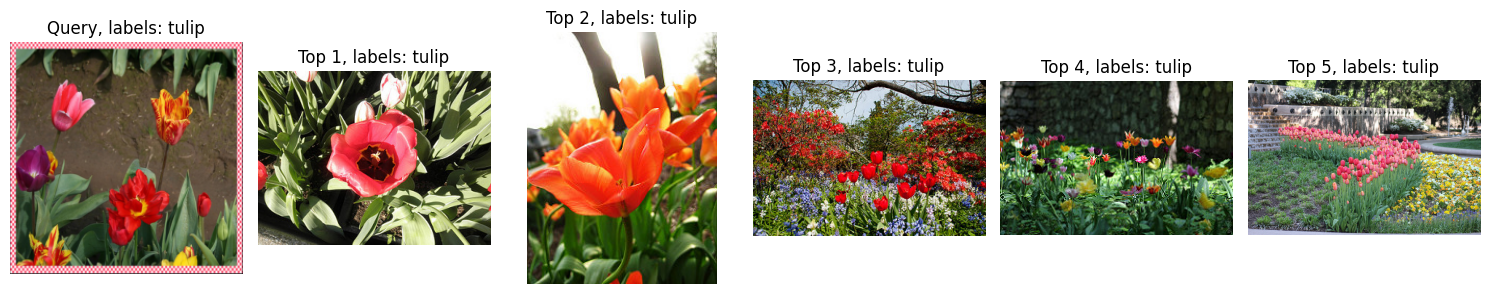

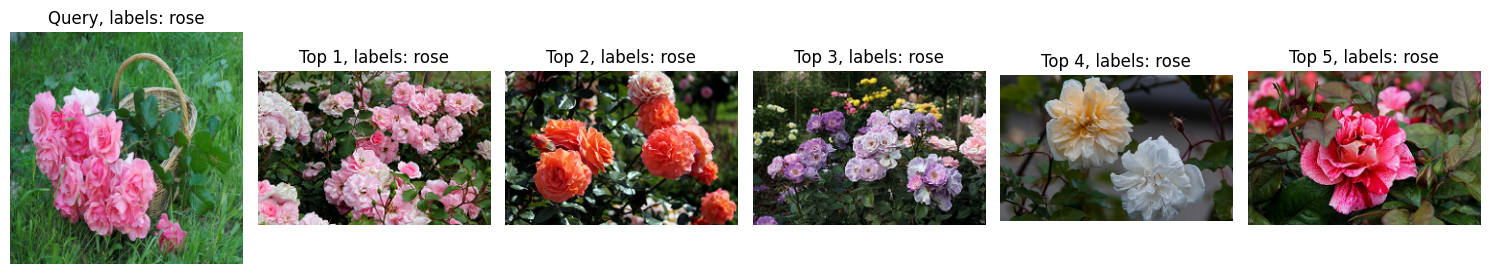

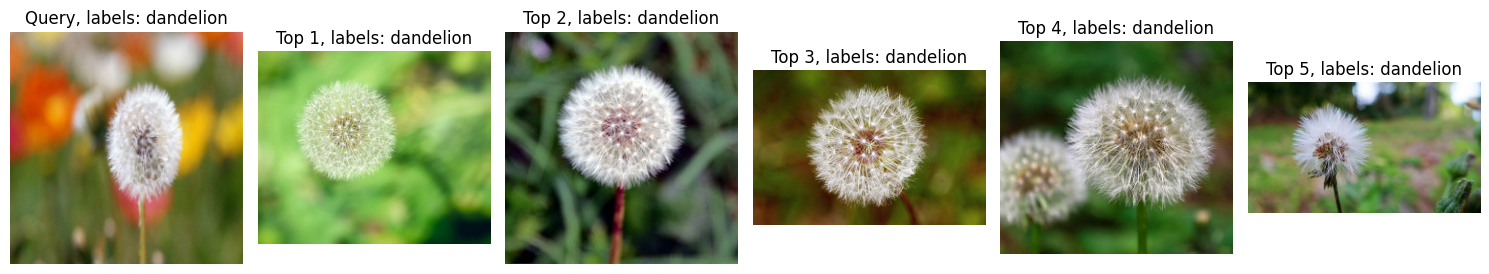

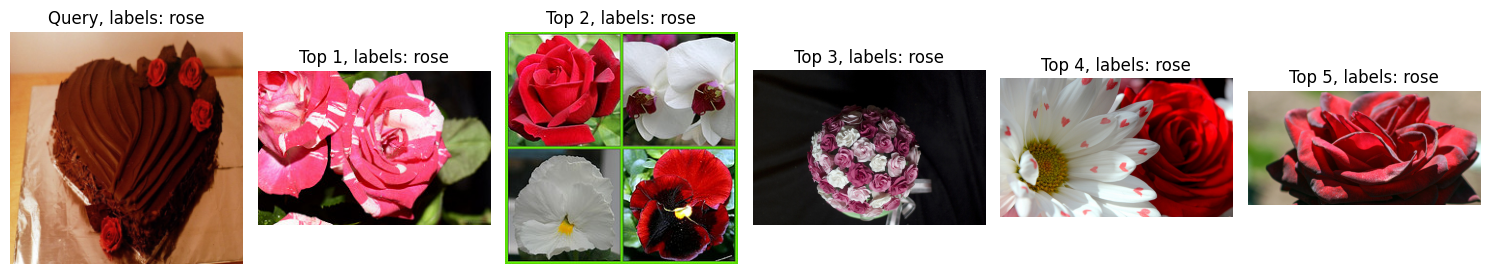

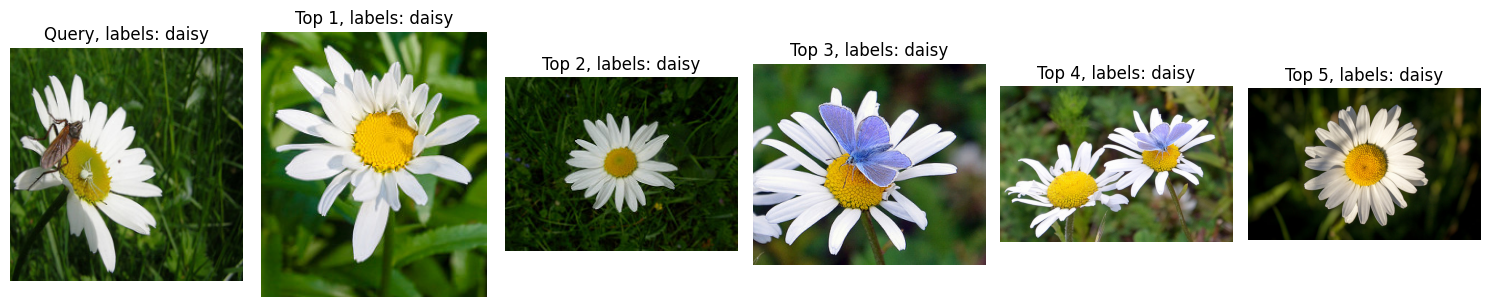

In [13]:
# Visualize top-5 results for 5 random query images
transform = val_dataset.transform
samples = [val_dataset[i] for i in torch.randint(0, len(val_dataset), (5,))]

for i, sample in enumerate(samples):
    query_tensor = sample['anchor'].unsqueeze(0).to(device)
    query_emb = model(query_tensor)
    query_emb = torch.nn.functional.normalize(query_emb, dim=1)
    query_np = query_emb.detach().cpu().numpy().astype(np.float32)

    _, top5_indices = index.search(query_np, 5)

    image = sample['anchor']
    image = transforms.ToPILImage()(image)
    # Plot results
    plt.figure(figsize=(15, 3))
    plt.subplot(1, 6, 1)
    plt.imshow(image)
    plt.title("Query, labels: " + train_dataset.dataset.classes[sample['class_idx']])
    plt.axis('off')

    for j, (label, idx) in enumerate(zip(labels[top5_indices[0]], top5_indices[0])):
        img_path, _ = train_dataset.dataset.imgs[idx]
        img = Image.open(img_path).convert("RGB")
        plt.subplot(1, 6, j + 2)
        plt.imshow(img)
        plt.title(f"Top {j+1}" + f", labels: {train_dataset.dataset.classes[label]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [18]:
dataset = ContrastiveDataset(root_dir='data/flowers', n_neg=3)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4, drop_last=True)
# Get emdeds
embeddings, labels = inference_embeddings(model, loader, device)  # shape [N, D]
embeddings_np = embeddings.numpy().astype(np.float32)
# Save embeds if we need
with open("data/embeddings.pkl", "wb") as f:
    pickle.dump((embeddings_np, labels), f)
    print("Embeddings saved to data/embeddings.pkl")

Embedding: 100%|██████████| 67/67 [00:12<00:00,  5.35it/s]


Embeddings saved to data/embeddings.pkl


In [16]:
images_paths = [img_path for img_path, _ in dataset.dataset.imgs]

with open("data/images_paths.pkl", "wb") as f:
    pickle.dump(images_paths, f)